# Probabilistic Power Curve Estimation using Keras & TensorFlow

In the previous ML lecture, we learned how to train a deterministic ANN to predict a given quantity. A single point estimate, however, cannot tell us *how confident* the model is, as we also learned about uncertainty that exists in our wind energy problems.... For a power curve estimation of a single turbine, for example, these deterministic models cannot capture the natural scatter we see - check out the plot for power output of turbine **T01** in our example wind farm today.

In this exercise we explore **three** complementary ways to quantify that uncertainty:

| Approach | Idea |
|---|---|
| **Part A – Quantile Regression FFNN** | Train separate networks for the 25th, 50th and 75th percentiles using the *Pinball loss*. Simple, interpretable, works well on tabular data. |
| **Part B – Monte Carlo (MC) Dropout** | Keep **Dropout active at inference time** so each forward pass samples a slightly different network. Run $T$ stochastic forward passes and treat the spread as an uncertainty estimate — without any extra training cost. |
| **Part D – Full Probabilistic FFNN (TensorFlow Probability)** | Make the network output the **parameters of a probability distribution** directly, trained by maximising likelihood. One forward pass (aka single run of the model) gives the full distribution. |

 <img src="https://i.imgur.com/CjJLXQt.png" alt="Power Curve" style="float: left; width: 1500px;"/>

<br> 
<br>
<br>
<br>
<br>
<br>
<br>



### A note on environments
This notebook targets TensorFlow **2.18.1**, which defaults to **Keras 3**. So we will need to add `tf-keras` onto our `Env_2026_edu` environment with the first cell below

> If `import tf_keras` fails in your environment, for now follow along and later, add `tf-keras` to the `pip:` section of `Env_2026_edu.yml` alongside `tensorflow-probability==0.24.0`.


In [1]:
# Environment setup: tensorflow_probability (Part D) needs the legacy tf_keras package
# alongside TF 2.18.1's default Keras 3. Safe to re-run; no-op if already installed.
%pip install -q tf-keras


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1 · Load and prepare data


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = r"data\Data_TimeSeries.csv"
dataset = pd.read_csv(file, delimiter=',')

dataset.Timestamp = dataset.Timestamp.str.replace(r'\+00:00', '', regex=True)
dataset.Timestamp = pd.to_datetime(dataset.Timestamp)
dataset.set_index('Timestamp', inplace=True)
dataset.sort_index(inplace=True)
dataset

,Turbine_ID,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Amb_WindSpeed_Min,Amb_WindSpeed_Max,Grd_Prod_Pwr_Avg,Grd_Prod_Pwr_Std,Grd_Prod_Pwr_Min,Grd_Prod_Pwr_Max,Gen_RPM_Avg,Gen_RPM_Std,Gen_RPM_Min,Gen_RPM_Max,Blds_PitchAngle_Avg,Blds_PitchAngle_Std,Blds_PitchAngle_Min,Blds_PitchAngle_Max
Timestamp,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,T01,5.6,1.1,1.5,10.0,291.5,62.9,129.6,428.7,1313.7,47.9,1239.2,1460.9,-1.5,0.4,-2.2,-0.2
2017-01-01 00:00:00,T06,5.8,0.9,2.5,9.7,378.1,71.9,239.1,592.8,1318.6,52.4,1236.3,1464.0,-1.7,0.4,-2.3,0.6
2017-01-01 00:00:00,T07,6.0,0.9,1.7,12.2,384.7,59.4,242.5,618.4,1336.5,47.6,1255.3,1513.4,-1.8,0.3,-2.2,-1.1
2017-01-01 00:00:00,T11,7.9,1.2,2.4,14.6,859.8,185.9,412.2,1221.3,1596.9,68.6,1377.7,1679.5,-2.2,0.2,-3.3,-0.8
2017-01-01 00:10:00,T01,4.9,1.0,1.5,18.5,207.5,55.0,98.0,413.8,1271.3,27.6,1229.4,1410.6,-1.0,0.4,-2.3,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:40:00,T11,5.4,0.9,1.6,17.6,288.2,63.4,125.4,415.4,1268.9,37.3,1221.0,1421.2,-1.5,0.5,-2.4,-0.2
2017-12-31 23:50:00,T01,5.4,0.4,4.0,6.6,242.6,41.1,151.9,340.6,1250.7,4.7,1239.8,1273.1,-1.6,0.3,-2.1,-1.0
2017-12-31 23:50:00,T06,4.7,0.8,2.2,6.5,182.8,73.3,27.2,340.3,1249.4,6.6,1229.6,1270.8,-1.0,0.4,-1.7,0.6


## Let's extract for a single turbine only

In [8]:
# How many turbines in the WF?
dataset['Turbine_ID'].unique()

array(['T01', 'T06', 'T07', 'T11'], dtype=object)

In [9]:
dataset_T01 = dataset[dataset.Turbine_ID == 'T01']
dataset_T01

,Turbine_ID,Amb_WindSpeed_Avg,Amb_WindSpeed_Std,Amb_WindSpeed_Min,Amb_WindSpeed_Max,Grd_Prod_Pwr_Avg,Grd_Prod_Pwr_Std,Grd_Prod_Pwr_Min,Grd_Prod_Pwr_Max,Gen_RPM_Avg,Gen_RPM_Std,Gen_RPM_Min,Gen_RPM_Max,Blds_PitchAngle_Avg,Blds_PitchAngle_Std,Blds_PitchAngle_Min,Blds_PitchAngle_Max
Timestamp,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,T01,5.6,1.1,1.5,10.0,291.5,62.9,129.6,428.7,1313.7,47.9,1239.2,1460.9,-1.5,0.4,-2.2,-0.2
2017-01-01 00:10:00,T01,4.9,1.0,1.5,18.5,207.5,55.0,98.0,413.8,1271.3,27.6,1229.4,1410.6,-1.0,0.4,-2.3,0.5
2017-01-01 00:20:00,T01,4.9,1.0,1.6,10.5,199.7,61.9,60.6,387.7,1270.4,30.8,1226.7,1444.1,-1.0,0.5,-2.2,0.1
2017-01-01 00:30:00,T01,4.5,0.9,0.4,8.2,153.6,44.9,46.1,288.6,1256.1,11.8,1228.1,1300.0,-0.6,0.5,-1.9,0.5
2017-01-01 00:40:00,T01,4.2,0.9,0.5,10.1,101.4,35.7,12.6,175.7,1252.9,11.2,1221.2,1294.1,-0.4,0.4,-1.3,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 23:10:00,T01,6.3,0.5,5.1,7.3,441.5,65.3,304.4,565.1,1394.3,64.3,1260.4,1491.3,-1.9,0.1,-2.1,-1.6
2017-12-31 23:20:00,T01,6.4,0.6,4.7,7.8,446.8,89.2,219.7,564.3,1403.6,75.6,1243.7,1487.2,-2.0,0.1,-2.2,-1.5
2017-12-31 23:30:00,T01,5.3,0.4,4.3,6.2,216.1,34.8,158.5,306.2,1250.1,3.4,1240.3,1260.2,-1.4,0.3,-1.9,-1.0


## 2 · Filter for normal operation using Clustering Algorithms

We'll implement Gaussian Mixture Models (GMMs) for this

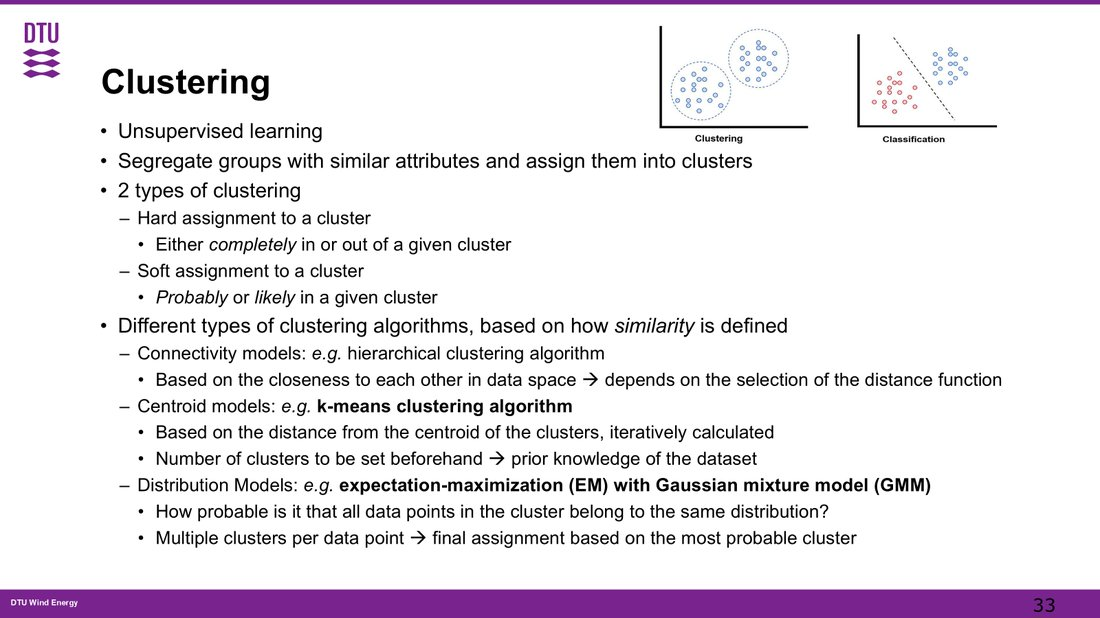

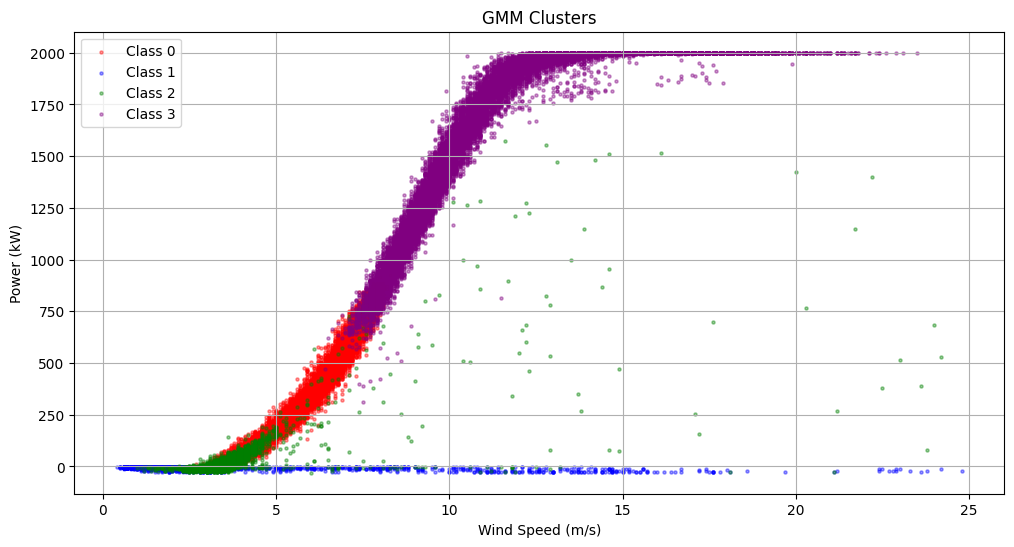

In [10]:
import sklearn.mixture
from sklearn.model_selection import train_test_split

Num_dataset_T01 = dataset_T01.drop(columns='Turbine_ID')

n_components = 4
GM_model = sklearn.mixture.GaussianMixture(n_components=n_components, random_state=42).fit(Num_dataset_T01)
all_classes = GM_model.predict(Num_dataset_T01)

colors = ['red', 'blue', 'green', 'purple']
plt.figure(figsize=(12, 6))
for i in range(n_components):
    mask = all_classes == i
    plt.scatter(Num_dataset_T01.loc[mask, 'Amb_WindSpeed_Avg'],
                Num_dataset_T01.loc[mask, 'Grd_Prod_Pwr_Avg'],
                c=colors[i], label=f'Class {i}', alpha=0.4, s=5)
plt.xlabel('Wind Speed (m/s)'); plt.ylabel('Power (kW)')
plt.title('GMM Clusters'); plt.legend(); plt.grid(); plt.show()


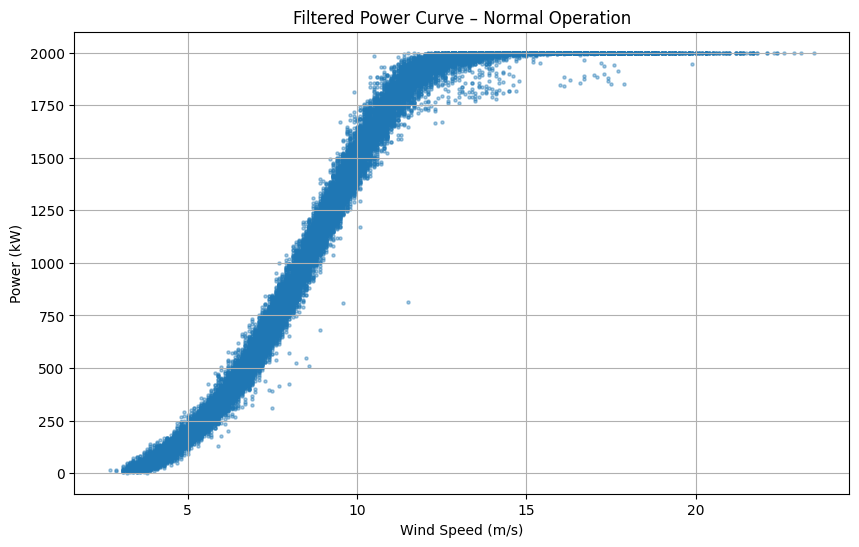

Normal operating samples: 34365


In [12]:
# Inspect the GMM cluster plot above, then fill in the class indices
# that follow the nominal power curve (i.e. "normal operation")
normal_classes = [0, 3]   # ← fill in, e.g. [0, 3]
filtered_data  = Num_dataset_T01[np.isin(all_classes, normal_classes)]

plt.figure(figsize=(10, 6))
plt.scatter(filtered_data['Amb_WindSpeed_Avg'], filtered_data['Grd_Prod_Pwr_Avg'], alpha=0.4, s=5)
plt.xlabel('Wind Speed (m/s)'); plt.ylabel('Power (kW)')
plt.title('Filtered Power Curve – Normal Operation'); plt.grid(); plt.show()
print(f'Normal operating samples: {len(filtered_data)}')


## 3 · Define inputs / output & split


- training: train the model (most data needed here - rule of thumb: Sum of $w_i$ and $b_i$/ Sum of Data ~ 70%)
- validation: further training of what the architecure should look like, e.g number of layers, neurons, activation function, epochs, bathc size, drop-out. <- this is the BEST MODEL (~15%)
- test: here we test this BEST DATA (~15%)

In [13]:
X = filtered_data[['Amb_WindSpeed_Avg', 'Amb_WindSpeed_Std']]
Y = filtered_data[['Grd_Prod_Pwr_Avg']]

X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.25, shuffle=True, random_state=42)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


Train: (20619, 2)  Val: (6873, 2)  Test: (6873, 2)


## 4 · Scale the data


In [14]:
from sklearn.preprocessing import MinMaxScaler

Xscaler = MinMaxScaler(feature_range=(0, 1))
X_train_sc = Xscaler.fit_transform(X_train)
X_val_sc   = Xscaler.transform(X_val)
X_test_sc  = Xscaler.transform(X_test)

Yscaler = MinMaxScaler(feature_range=(0, 1))
Y_train_sc = Yscaler.fit_transform(Y_train)
Y_val_sc   = Yscaler.transform(Y_val)
Y_test_sc  = Yscaler.transform(Y_test)


## 4b · Sanity check: do Train / Val / Test cover the same range?

Before trusting any model trained on `X_train_sc`, it's worth checking that the validation and test sets aren't asking the network to **extrapolate** beyond what it saw in training.

This matters for two concrete reasons:

- **The scaler was fit only on `X_train` / `Y_train`.** If `X_val` or `X_test` contain wind speeds or power values outside the training range, their *scaled* values might fall outside `[0, 1]` — the network is now working in a region it was never calibrated for.
- **Neural networks are poor extrapolators.** Inside the training range, an FFNN interpolates reasonably well between seen examples. Outside it, predictions can silently become unreliable — nothing in the code will warn you, the model will just confidently output something wrong.

A quick boxplot comparison, plus a coverage check, catches this before it becomes a hard-to-debug modelling issue.

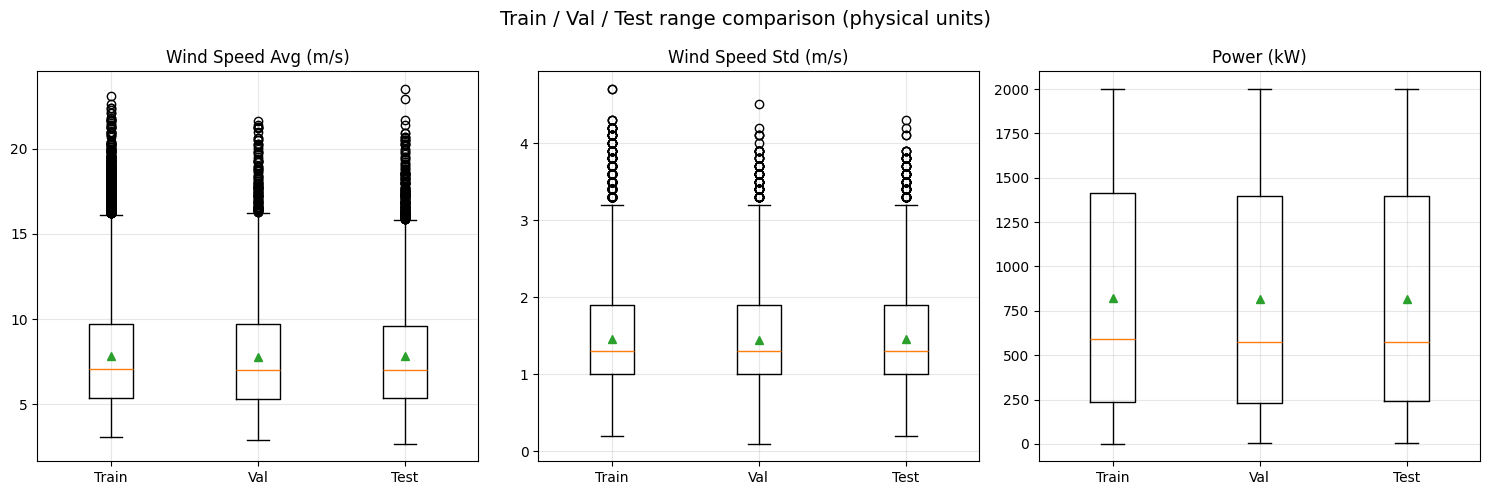

=== Coverage check: does the Train range cover Val/Test? ===
Wind Speed Avg (m/s)   Train range: [   3.10,   23.10]  ->  Val outside:  0.0%   Test outside:  0.0%
Wind Speed Std (m/s)   Train range: [   0.20,    4.70]  ->  Val outside:  0.0%   Test outside:  0.0%
Power (kW)             Train range: [   1.70, 2000.10]  ->  Val outside:  0.0%   Test outside:  0.0%


In [15]:
# Sanity check: compare Train / Val / Test ranges, and quantify any extrapolation risk
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vars_to_check = {
    'Wind Speed Avg (m/s)': (X_train['Amb_WindSpeed_Avg'], X_val['Amb_WindSpeed_Avg'], X_test['Amb_WindSpeed_Avg']),
    'Wind Speed Std (m/s)': (X_train['Amb_WindSpeed_Std'], X_val['Amb_WindSpeed_Std'], X_test['Amb_WindSpeed_Std']),
    'Power (kW)':           (Y_train['Grd_Prod_Pwr_Avg'],  Y_val['Grd_Prod_Pwr_Avg'],  Y_test['Grd_Prod_Pwr_Avg']),
}

for ax, (name, (tr, va, te)) in zip(axes, vars_to_check.items()):
    ax.boxplot([tr, va, te], showmeans=True)
    ax.set_xticklabels(['Train', 'Val', 'Test'])
    ax.set_title(name)
    ax.grid(alpha=0.3)

plt.suptitle('Train / Val / Test range comparison (physical units)', fontsize=14)
plt.tight_layout()
plt.show()

# Quantify: what fraction of Val/Test falls OUTSIDE the training range?
# (i.e. would be scaled to <0 or >1 by a scaler fit only on Train)
print('=== Coverage check: does the Train range cover Val/Test? ===')
for name, (tr, va, te) in vars_to_check.items():
    lo, hi = tr.min(), tr.max()
    va_out = ((va < lo) | (va > hi)).mean()
    te_out = ((te < lo) | (te > hi)).mean()
    print(f'{name:22s} Train range: [{lo:7.2f}, {hi:7.2f}]  '
          f'->  Val outside: {va_out:5.1%}   Test outside: {te_out:5.1%}')

Reading the graph:
- mean - traingle
- median - oragne line
- 

# Uncertainty in Deep Learning

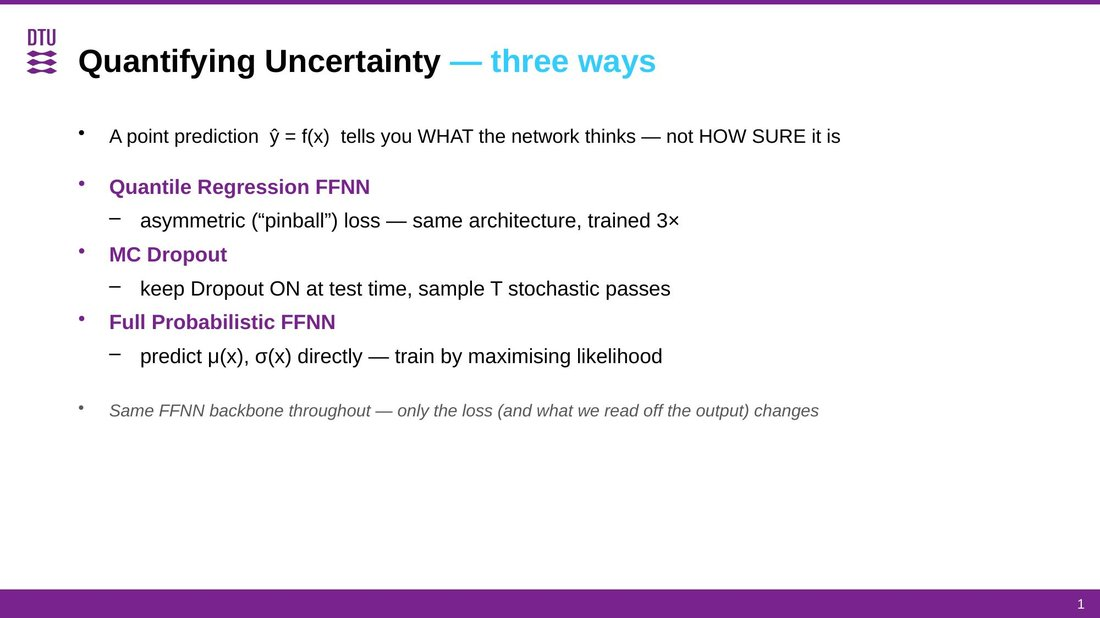

---
# Part A · Quantile Regression FFNN

## Concept

The **Pinball loss** asymmetrically penalises over- and under-prediction based on quantile $\tau$:

$$\mathcal{L}_\tau(y, \hat{y}) = \begin{cases} \tau \cdot (y - \hat{y}) & \text{if } y \geq \hat{y} \\ (1-\tau) \cdot (\hat{y} - y) & \text{otherwise} \end{cases}$$

Minimising this loss steers the network output towards the $\tau$-th quantile of the conditional distribution $p(y|x)$.  
No distributional assumptions are needed — this is a fully **non-parametric** approach.


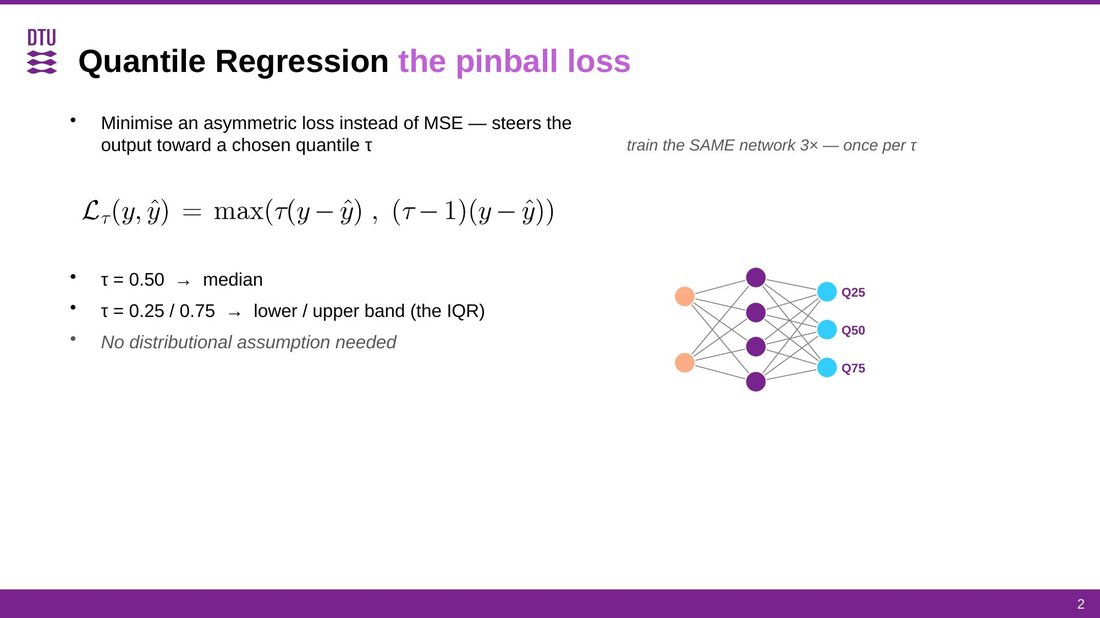

## A1 · Implement the Pinball Loss


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow.keras.backend as K

def pinball_loss(tau):
    """Returns a Keras-compatible loss for quantile tau."""
    def loss(y_true, y_pred):
        error = y_true - y_pred
        return K.mean(K.maximum(tau * error, (tau - 1) * error), axis=-1)
    loss.__name__ = f'pinball_{tau}'
    return loss

# Sanity check: for tau=0.5 this should equal 0.5 * MAE
y_t = tf.constant([[1.0], [2.0], [3.0]])
y_p = tf.constant([[0.5], [2.5], [3.5]])
print('Pinball τ=0.5:', pinball_loss(0.5)(y_t, y_p).numpy(),
      '  0.5*MAE:', (0.5 * tf.reduce_mean(tf.abs(y_t - y_p))).numpy())


Pinball τ=0.5: [0.25 0.25 0.25]   0.5*MAE: 0.25


## A2 · Build and train quantile networks

**Keras 3 note:** we use `tf.keras.Input(shape=(n_inputs,))` as the first element of the `Sequential` list rather than `input_dim=` on the first `Dense` layer. Both work under TF 2.18.1, but `input_dim` now triggers a `UserWarning` recommending the `Input` layer instead.


*Dense* means stupid ->simple/the easiest layers


--- Training τ = 0.25 ---
  Final val loss: 0.0071

--- Training τ = 0.5 ---
  Final val loss: 0.0086

--- Training τ = 0.75 ---
  Final val loss: 0.0068


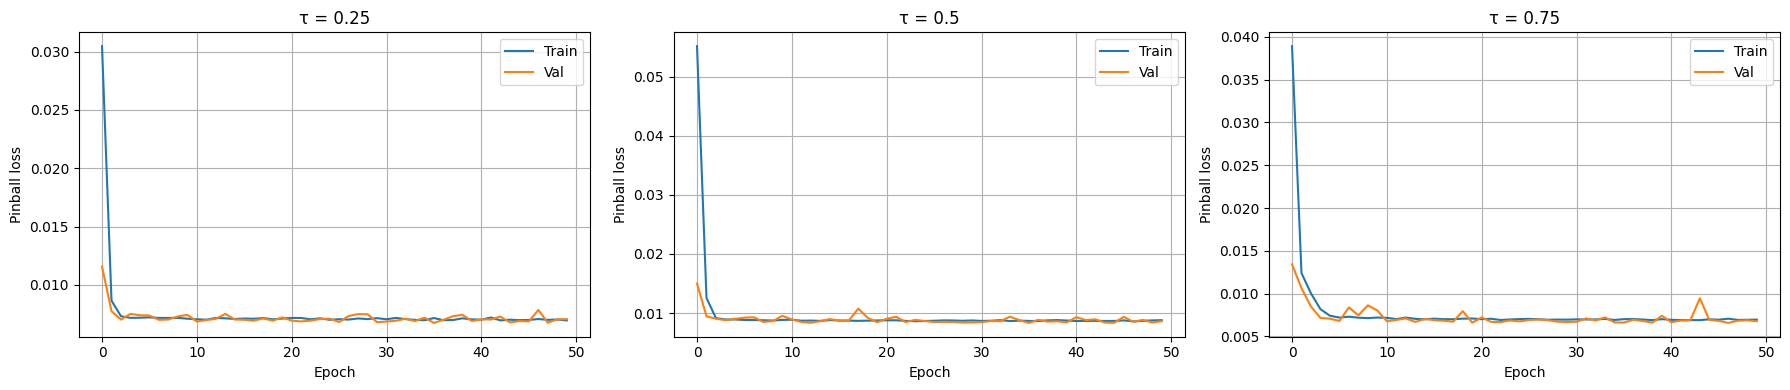

In [22]:
def build_quantile_model(tau, n_inputs=2):
    K.clear_session()
    model = Sequential([
        tf.keras.Input(shape=(n_inputs,)),
        Dense(45 , activation='relu', kernel_initializer='glorot_uniform'), # choose how many neurons per layer
        Dense(15, activation='relu'), # choose how many neurons per layer
        Dense(1)  # single output – no activation
    ])
    model.compile(loss=pinball_loss(tau), optimizer='adam')
    return model

quantile_models  = {}
quantile_history = {}

for tau in [0.25, 0.50, 0.75]:
    print(f'\n--- Training τ = {tau} ---')
    model = build_quantile_model(tau)
    hist  = model.fit(
        X_train_sc, Y_train_sc,
        validation_data=(X_val_sc, Y_val_sc),
        epochs=50, batch_size=64, verbose=0
    )
    quantile_models[tau]  = model
    quantile_history[tau] = hist
    print(f'  Final val loss: {hist.history["val_loss"][-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (tau, hist) in zip(axes, quantile_history.items()):
    ax.plot(hist.history['loss'], label='Train')
    ax.plot(hist.history['val_loss'], label='Val')
    ax.set_title(f'τ = {tau}'); ax.legend(); ax.grid()
    ax.set_xlabel('Epoch'); ax.set_ylabel('Pinball loss')
plt.tight_layout(); plt.show()


Epochs are numbers of interactions to fit our weight and biases 
- training loses, we would expect to be lower than the validation ones
(but that is not always the case)

## A3 · Visualise the prediction intervals


215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


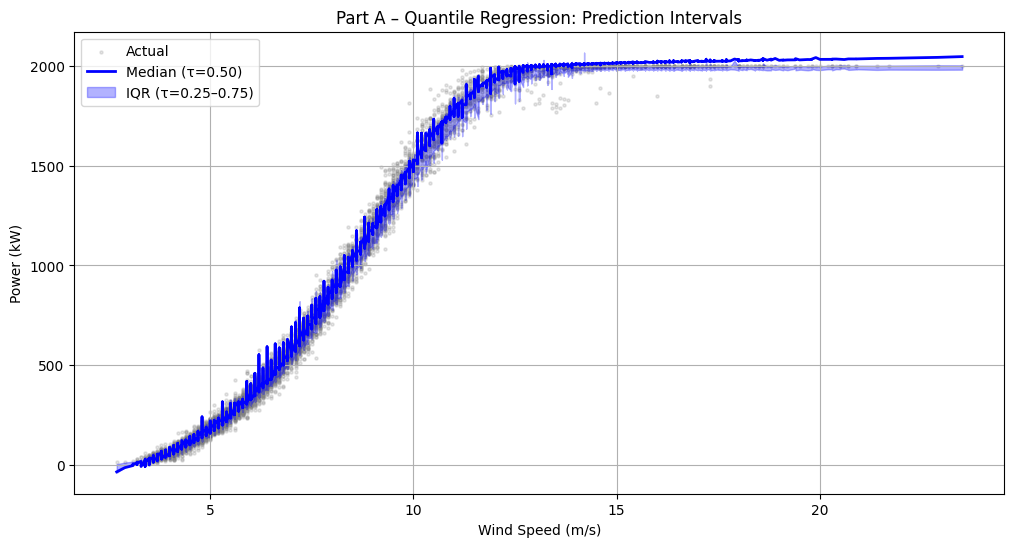

In [23]:
preds     = {}
wind_test = Xscaler.inverse_transform(X_test_sc)[:, 0]
Y_test_kw = Yscaler.inverse_transform(Y_test_sc).ravel()

for tau, model in quantile_models.items():
    preds[tau] = Yscaler.inverse_transform(model.predict(X_test_sc)).ravel()

order = np.argsort(wind_test)

plt.figure(figsize=(12, 6))
plt.scatter(wind_test, Y_test_kw, alpha=0.2, s=5, color='grey', label='Actual')
plt.plot(wind_test[order], preds[0.50][order], 'b-', lw=2, label='Median (τ=0.50)')
plt.fill_between(wind_test[order], preds[0.25][order], preds[0.75][order],
                 alpha=0.3, color='blue', label='IQR (τ=0.25–0.75)')
plt.xlabel('Wind Speed (m/s)'); plt.ylabel('Power (kW)')
plt.title('Part A – Quantile Regression: Prediction Intervals')
plt.legend(); plt.grid(); plt.show()


## A4 · Evaluate coverage


Empirical coverage of Q25-Q75 interval: 47.1%  (expected ~50%)


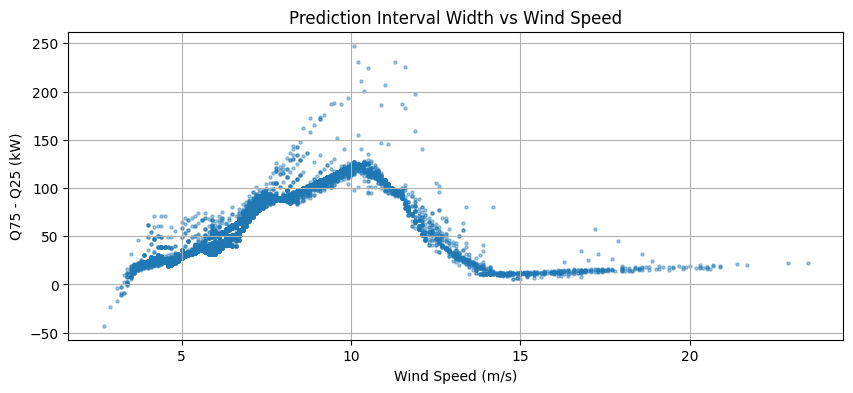

In [24]:
# compute the fraction of test points that fall inside [Q25, Q75]
coverage = np.mean((Y_test_kw >= preds[0.25]) & (Y_test_kw <= preds[0.75]))
print(f'Empirical coverage of Q25-Q75 interval: {coverage:.1%}  (expected ~50%)')

interval_width = preds[0.75] - preds[0.25]
plt.figure(figsize=(10, 4))
plt.scatter(wind_test, interval_width, s=5, alpha=0.4)
plt.xlabel('Wind Speed (m/s)'); plt.ylabel('Q75 - Q25 (kW)')
plt.title('Prediction Interval Width vs Wind Speed'); plt.grid(); plt.show()


Quantile regression makes a falsifiable promise: if the Q25 and Q75 networks have learned the true 25th and 75th percentiles of `p(power | wind speed)`, then by definition **50% of real observations should fall inside that band** — no more, no less. That's not a modelling choice, it's what "25th percentile" and "75th percentile" mean. So we can check the model against its own promise using nothing but the test set.

**Reading the coverage number:**
- ≈ 50% → well-calibrated: the band is exactly as wide as it should be
- **> 50%** (as you'll likely see here) → the band is **too wide** — Q25 is a bit too low and/or Q75 is a bit too high. Conservative, but not dangerously wrong: the true value is being captured *more* often than promised, not less.
- < 50% → the band is **too narrow** — this is the direction you should worry about, since it means the model is overconfident and the true value falls outside the "50% interval" more often than it should.

A common cause of over-coverage here: the three τ-networks are trained **completely independently**, so nothing enforces Q25 ≤ Q50 ≤ Q75 at every input, and nothing pulls the two outer networks toward the tightest interval that still contains 50% of the data. (You can check for outright inconsistency — "quantile crossing" — with `(preds[0.25] > preds[0.50]).mean()`.)

**Reading the width-vs-wind-speed plot:**

This plot answers a different question: *where* is the model uncertain, physically? A wind turbine's power output isn't equally noisy everywhere — this plot should trace out the turbine's own operating envelope:

| Wind speed region | Expected interval width | Why |
|---|---|---|
| Near cut-in (~3–5 m/s) | narrow | power ≈ 0, little to vary |
| Transition (~6–10 m/s) | widening sharply | turbulence + pitch-control switching cause real scatter |
| Around rated (~10–11 m/s) | **widest** | most variable operating region |
| Above rated (~12–15 m/s) | narrows again | controller pins power at rated, regardless of wind |
| Far above rated (>15 m/s) | noisy / slight uptick | very few samples out here — each quantile estimate is less reliable |

If your plot doesn't show this shape, that's worth investigating — it would suggest the networks haven't learned the physical structure of the power curve, not just that they're miscalibrated.

---
# Part B · MC Dropout for Uncertainty Estimation

## Concept

Dropout randomly zeroes activations during training.  
**MC Dropout** (Gal & Ghahramani 2016) keeps this stochasticity active **at test time** — each forward pass is equivalent to sampling a different 'thinned' network.

$$\mu(x) = \frac{1}{T}\sum_{t=1}^{T}\hat{y}_t(x), \qquad \sigma(x) = \sqrt{\frac{1}{T}\sum_{t=1}^{T}(\hat{y}_t(x)-\mu(x))^2}$$

This is a lightweight way to get approximate **Bayesian uncertainty** without changing the loss or adding parameters.

**Key implementation trick:** pass `training=True` to `model()` at inference time, which keeps Dropout layers in 'train mode' (stochastic).


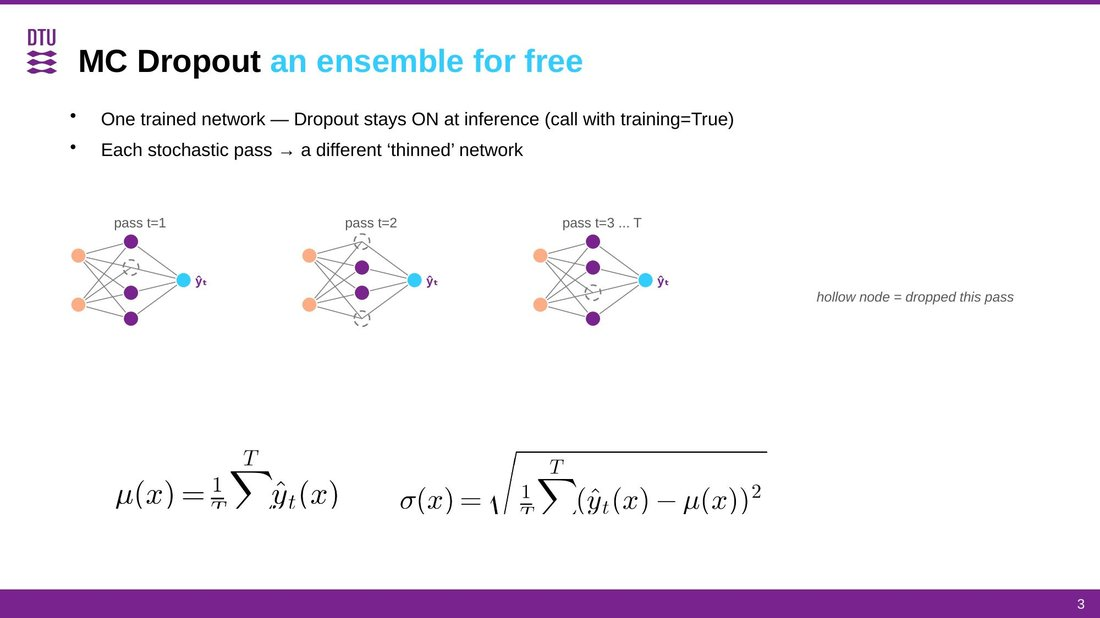

### What "approximate Bayesian" and `training=True` actually mean

**What "Bayesian" would normally require:** A fully Bayesian neural network doesn't learn one value for each weight — it learns a distribution over each weight (e.g., "this weight is probably around 0.3, but could plausibly be anywhere from 0.1 to 0.5"). At prediction time, you'd sample different weight-sets from those distributions, run the network multiple times, and the spread in outputs reflects how uncertain the model is. This is principled, but expensive: you roughly double the number of parameters (mean + variance per weight) and need a much more complex, non-standard training procedure (variational inference).

**What Gal & Ghahramani showed (2016):** If your network already has Dropout layers trained completely normally, with the standard loss (MSE, MAE, etc), then Dropout is, mathematically, performing an approximation to exactly that kind of Bayesian weight-uncertainty. Each time Dropout randomly zeroes out a different subset of neurons, it's roughly equivalent to sampling a different set of "likely" or "possible" weights from an implicit distribution. Nobody designed Dropout for this as it was invented purely as a regularizer to prevent overfitting, but it turns out to have this second, useful property for free.

**The `training=True` trick:** Dropout only randomly zeroes neurons while `training=True`. Normally, `model.predict(X)` (or just calling the model) sets `training=False` automatically — Dropout switches off, and every call gives the same, stable answer, which is what you want for a deployed model. `model(X, training=True)` overrides that: it forces Dropout to keep masking neurons *even at inference*, with no weights being updated. Call it `T` times on the same input and each pass uses a different random subset of "active" neurons, so you get `T` slightly different predictions — their mean is `μ(x)`, their spread is `σ(x)`.

**This only works if the network actually has Dropout layers**. On a plain MSE model with no Dropout, `training=True` changes nothing. That is exactly why `mc_model` below deliberately inserts `Dropout(0.2)` between the Dense layers.

## B1 · Build and train the MC Dropout model


In [25]:
from tensorflow.keras.layers import Dropout

K.clear_session()

DROP_RATE = 0.2

mc_model = Sequential([
    tf.keras.Input(shape=(2,)),
    Dense(45 , activation='relu', kernel_initializer='glorot_uniform'), # how many neurons for this layer?
    Dropout(DROP_RATE), 
    Dense(15 , activation='relu'), # how many neurons for this layer?
    Dropout(DROP_RATE),
    Dense(1)   # single output
])

mc_model.compile(loss='mean_absolute_error', optimizer='adam')
mc_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 45)             │           135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           690 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

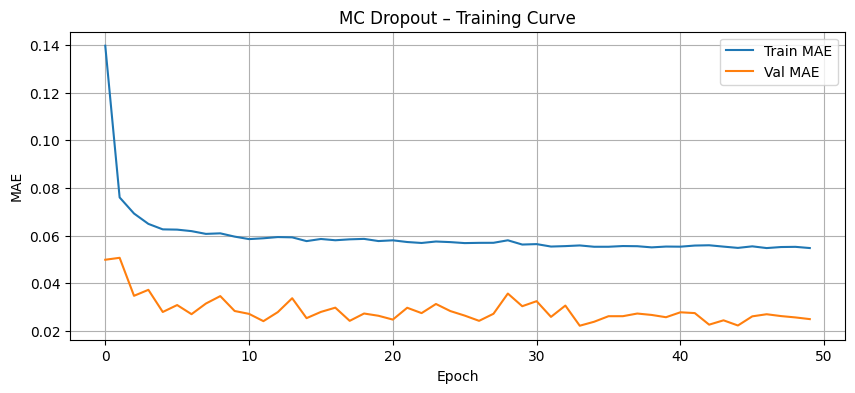

In [26]:
history_mc = mc_model.fit(
    X_train_sc, Y_train_sc,
    validation_data=(X_val_sc, Y_val_sc),
    epochs=50, batch_size=64, verbose=0, shuffle=True
)

plt.figure(figsize=(10, 4))
plt.plot(history_mc.history['loss'], label='Train MAE')
plt.plot(history_mc.history['val_loss'], label='Val MAE')
plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid()
plt.title('MC Dropout – Training Curve'); plt.show()


## B2 · Stochastic inference: $T$ forward passes


In [27]:
T = 100

# Each call to model(x, training=True) samples a different dropout mask
mc_preds_sc = np.array([mc_model(X_test_sc, training=True).numpy().ravel()
                        for _ in range(T)])  # shape: (T, n_test)

mc_preds_kw = np.array([Yscaler.inverse_transform(mc_preds_sc[t].reshape(-1,1)).ravel()
                        for t in range(T)])

mu_kw    = mc_preds_kw.mean(axis=0)
sigma_kw = mc_preds_kw.std(axis=0)

print(f'Average uncertainty σ: {sigma_kw.mean():.1f} kW')
print(f'Max uncertainty σ    : {sigma_kw.max():.1f} kW')


Average uncertainty σ: 121.8 kW
Max uncertainty σ    : 498.6 kW


## B3 · Visualise MC Dropout uncertainty bands


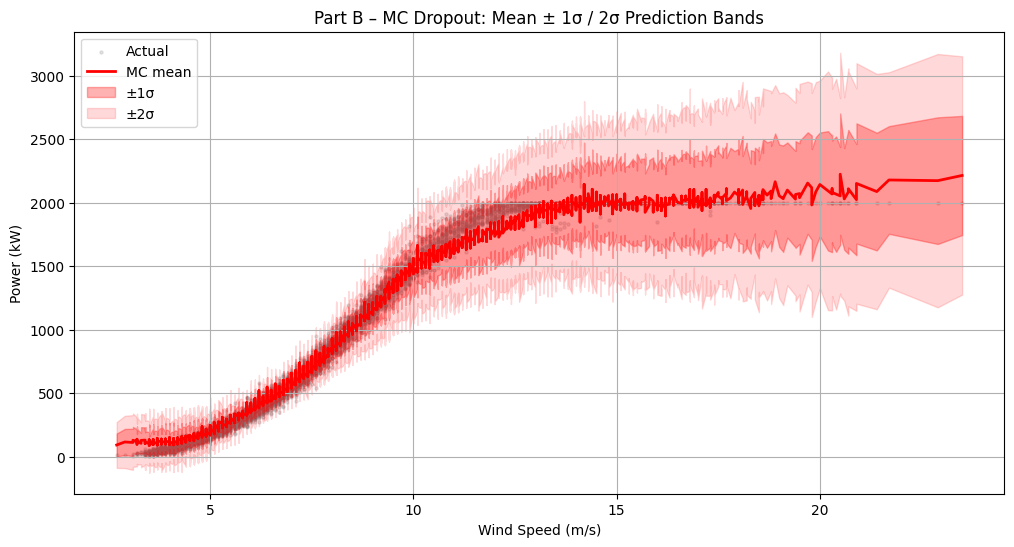

In [28]:
order2 = np.argsort(wind_test)

plt.figure(figsize=(12, 6))
plt.scatter(wind_test, Y_test_kw, alpha=0.2, s=5, color='grey', label='Actual')
plt.plot(wind_test[order2], mu_kw[order2], 'r-', lw=2, label='MC mean')
plt.fill_between(wind_test[order2],
                 (mu_kw - sigma_kw)[order2], (mu_kw + sigma_kw)[order2],
                 alpha=0.3, color='red', label='±1σ')
plt.fill_between(wind_test[order2],
                 (mu_kw - 2*sigma_kw)[order2], (mu_kw + 2*sigma_kw)[order2],
                 alpha=0.15, color='red', label='±2σ')
plt.xlabel('Wind Speed (m/s)'); plt.ylabel('Power (kW)')
plt.title('Part B – MC Dropout: Mean ± 1σ / 2σ Prediction Bands')
plt.legend(); plt.grid(); plt.show()


## B4 · Uncertainty vs wind speed


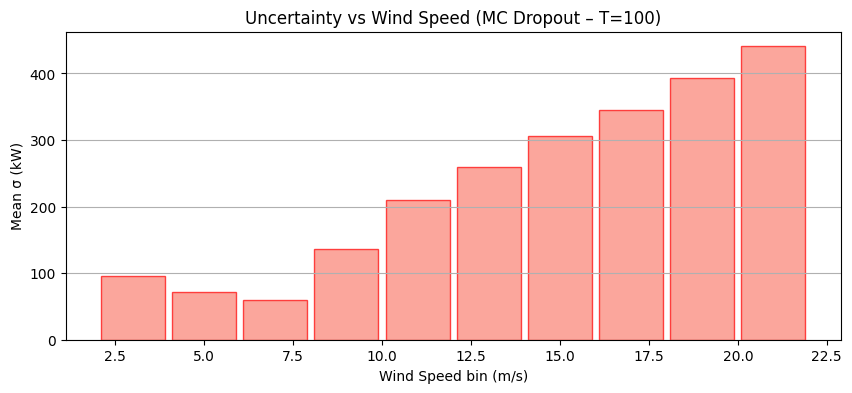

In [29]:
bins    = np.arange(0, 30, 2)
bin_idx = np.digitize(wind_test, bins)

bin_centers, bin_sigma, bin_counts = [], [], []
for b in np.unique(bin_idx):
    mask = bin_idx == b
    if mask.sum() > 5:
        bin_centers.append(bins[b-1] + 1)
        bin_sigma.append(sigma_kw[mask].mean())
        bin_counts.append(mask.sum())

plt.figure(figsize=(10, 4))
plt.bar(bin_centers, bin_sigma, width=1.8, alpha=0.7, color='salmon', edgecolor='red')
plt.xlabel('Wind Speed bin (m/s)'); plt.ylabel('Mean σ (kW)')
plt.title('Uncertainty vs Wind Speed (MC Dropout – T=100)')
plt.grid(axis='y'); plt.show()

# Interpretation:
# High σ in transition region (cut-in and rated transition zones) reflects
# genuine data scatter (aleatoric) and model uncertainty (epistemic) combined.


---
# Part D · Full Probabilistic FFNN with TensorFlow Probability

## Concept

Parts A and B both approximate uncertainty *around* a deterministic backbone. Part D takes a more direct route:

> Make the network output the **parameters of a probability distribution** — here $\mu(x)$ and $\sigma(x)$ of a Gaussian — instead of a single number. Train it by **maximising the likelihood** of the observed data under that distribution (equivalently, minimising the **Negative Log-Likelihood**, NLL).

$$p(y \mid x) = \mathcal{N}\big(y \mid \mu(x), \sigma(x)^2\big), \qquad \mathcal{L}_{\text{NLL}} = -\log p(y \mid x)$$

This models more the **aleatoric** (data) uncertainty — the network can genuinely say *'the data is inherently noisy here'*, unlike MC Dropout which mostly reflects **epistemic** (lack-of-training-data) uncertainty.


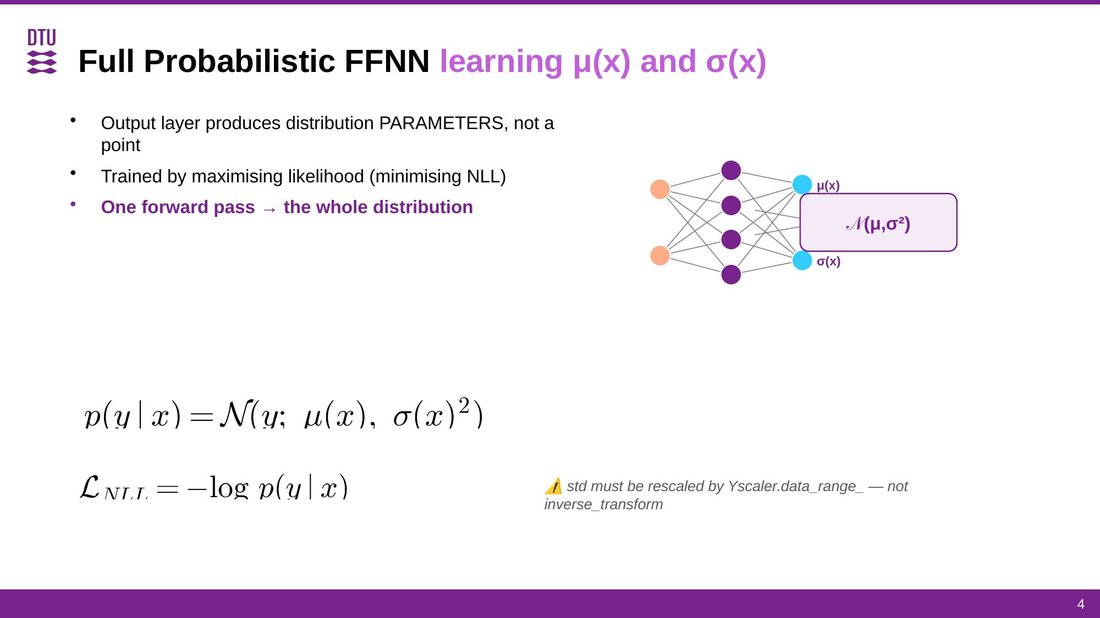

## D1 · Build the probabilistic model


In [ ]:
import tf_keras
import tensorflow_probability as tfp

tfd = tfp.distributions

def build_probabilistic_model(n_inputs=2):
    """Functional model (tf_keras) that outputs a tfd.Normal distribution."""
    inputs = tf_keras.Input(shape=(n_inputs,))

    x = tf_keras.layers.Dense(45, activation='relu')(inputs)
    x = tf_keras.layers.Dense(25, activation='relu')(x)   # ADDED 3rd hidden layer (unlike MC Dropout model and quantile model!!!!)
    x = tf_keras.layers.Dense(15, activation='relu')(x)

    # Output layer: 2 raw parameters -> [mu_raw, sigma_raw]
    params = tf_keras.layers.Dense(2)(x)

    # Wrap into a Normal distribution; softplus + epsilon keeps scale strictly positive
    dist = tfp.layers.DistributionLambda(
        lambda t: tfd.Normal(
            loc=t[..., 0:1],
            scale=1e-3 + tf.math.softplus(t[..., 1:2])
        )
    )(params)

    return tf_keras.Model(inputs=inputs, outputs=dist)

prob_model = build_probabilistic_model()
prob_model.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_3 (Dense)             (None, 45)                135       
                                                                 
 dense_4 (Dense)             (None, 25)                1150      
                                                                 
 dense_5 (Dense)             (None, 15)                390       
                                                                 
 dense_6 (Dense)             (None, 2)                 32        
                                                                 
 distribution_lambda_1 (Dis  ((None, 1),               0         
 tributionLambda)             (None, 1))                         
                                                           

### What `dist` actually is, and why NLL

**`dist` is not a tensor, it's a distribution object:** A normal `Dense(1)` layer outputs one number per input: a point guess. Here, `Dense(2)` outputs two raw numbers as they would come out of an NN layer. `DistributionLambda` turns that pair into an actual `tfd.Normal(loc, scale)` object with `.mean()`, `.stddev()`.

- `loc = t[..., 0:1]` → used directly as μ(x). A mean can be any real number, so no transformation is needed.
- `scale = 1e-3 + softplus(t[..., 1:2])` → used as σ(x). A std dev must be **strictly positive**, but a plain Dense layer can output negative numbers. `softplus` squashes any real number to a positive one; the tiny `+1e-3` just keeps σ safely away from exactly 0 (avoids `NaN` later when we divide by it).


## D2 · Negative Log-Likelihood loss & training

Because the model's output is a **distribution object**, the loss can call `.log_prob(y_true)` directly.

**Why NLL, not MSE:** MSE only makes sense when comparing two numbers — but `dist` isn't a number, it's a distribution. What we *can* compare a distribution to is a real, observed value: "how likely was this actual power reading, under the distribution the model just predicted?" That's `dist.log_prob(y_true)` — the log-probability the model assigns to what really happened.

$$\mathcal{L}_{\text{NLL}} = -\log p(y \mid x) = -\log\,\mathcal{N}\big(y;\ \mu(x),\ \sigma(x)^2\big)$$

Minimizing this loss means: *make the observed data as likely as possible, under the distribution the network predicts.* A model that predicts a very wrong μ(x), or a σ(x) far too narrow for the real scatter, assigns the true `y` a low probability → high loss. Get both μ(x) and σ(x) right, and the true `y` sits comfortably inside a well-matched bell curve → low loss.

**One line, two jobs:** Notice this single loss is training *both* outputs at once. μ(x) is pulled toward the local mean, σ(x) is pulled toward the local spread, simultaneously, from the same data, in one training run. Nothing separate needs to be fit for the std, it falls out of minimizing this one expression.

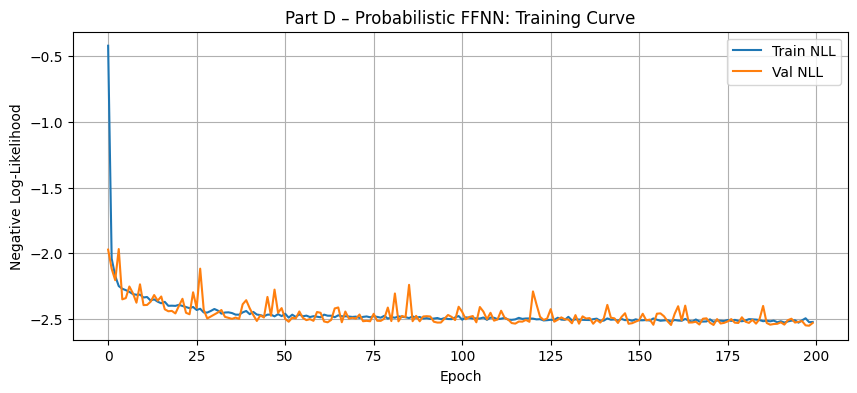

In [39]:
def nll_loss(y_true, y_pred):
    """Negative log-likelihood: y_pred is a tfd.Distribution, not a tensor."""
    return -y_pred.log_prob(y_true)

prob_model.compile(optimizer='adam', loss=nll_loss)

history_prob = prob_model.fit(
    X_train_sc, Y_train_sc,
    validation_data=(X_val_sc, Y_val_sc),
    epochs=200, batch_size=64, verbose=0
)

plt.figure(figsize=(10, 4))
plt.plot(history_prob.history['loss'], label='Train NLL')
plt.plot(history_prob.history['val_loss'], label='Val NLL')
plt.xlabel('Epoch'); plt.ylabel('Negative Log-Likelihood'); plt.legend(); plt.grid()
plt.title('Part D – Probabilistic FFNN: Training Curve')
plt.show()


## D3 · Extract mean & stddev directly (single forward pass!)

Unlike MC Dropout, we do **not** need multiple stochastic passes. `.mean()` and `.stddev()` give us everything in one call.

>  **Careful with scaling:** `Yscaler.inverse_transform()` correctly un-scales the *mean* (a linear transform handles offset + scale). The **standard deviation only needs the scale factor**, not the offset — so we multiply by `Yscaler.data_range_` rather than calling `inverse_transform` on it.


In [41]:
prob_out = prob_model(X_test_sc)
mu_sc    = prob_out.mean().numpy().ravel()
sigma_sc = prob_out.stddev().numpy().ravel()

mu_prob_kw    = Yscaler.inverse_transform(mu_sc.reshape(-1,1)).ravel()
y_range       = Yscaler.data_range_[0]     # (max - min) of Y_train — rescales sigma correctly
sigma_prob_kw = sigma_sc * y_range

print(f'Mean σ (Part D): {sigma_prob_kw.mean():.1f} kW')
print(f'Max  σ (Part D): {sigma_prob_kw.max():.1f} kW')


Mean σ (Part D): 45.3 kW
Max  σ (Part D): 158.5 kW


## D4 · Visualise & compare all three methods


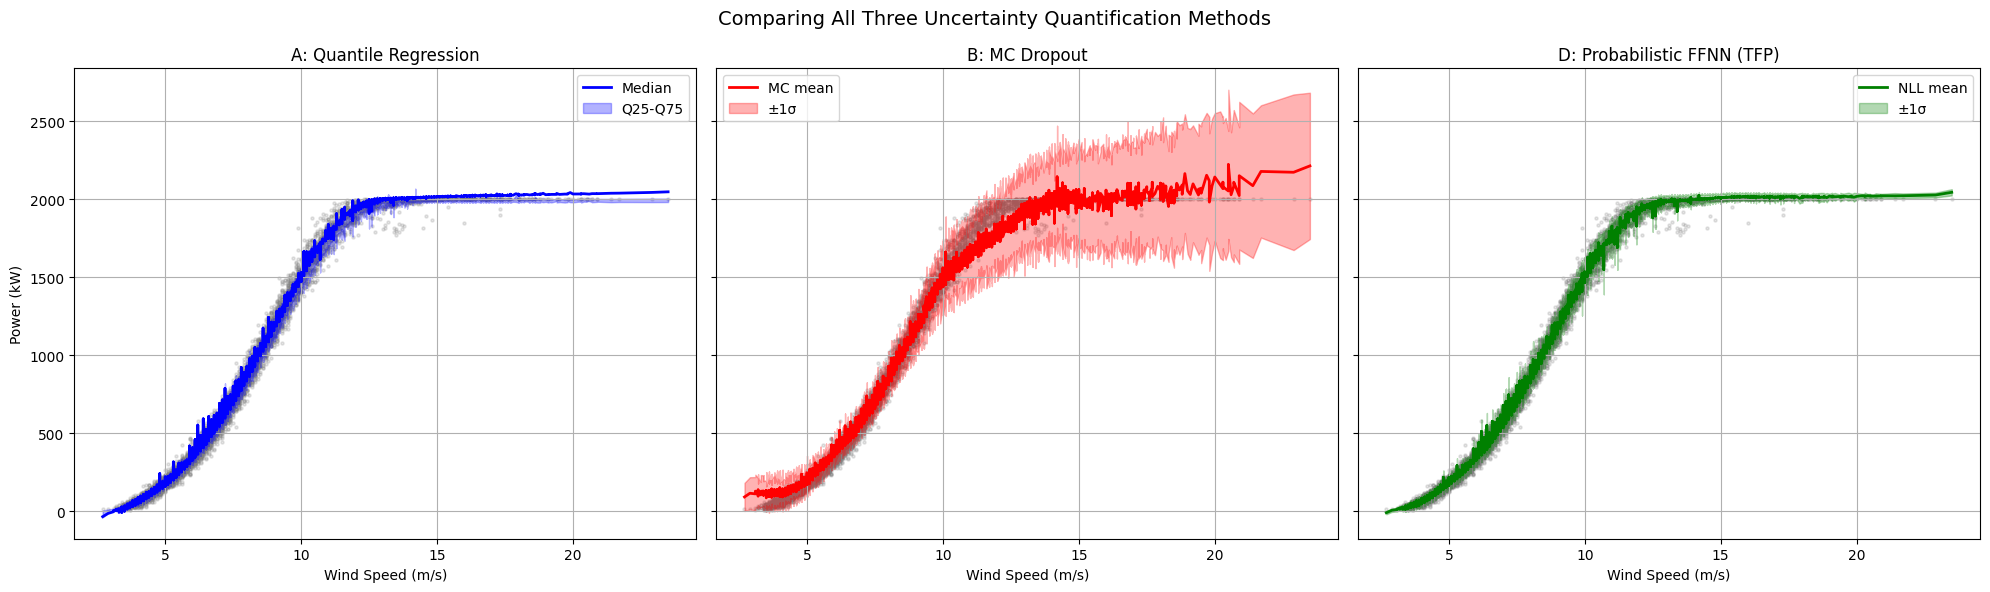

In [42]:
order3 = np.argsort(wind_test)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

axes[0].scatter(wind_test, Y_test_kw, alpha=0.2, s=5, color='grey')
axes[0].plot(wind_test[order], preds[0.50][order], 'b-', lw=2, label='Median')
axes[0].fill_between(wind_test[order], preds[0.25][order], preds[0.75][order], alpha=0.3, color='blue', label='Q25-Q75')
axes[0].set_title('A: Quantile Regression'); axes[0].legend(); axes[0].grid()

axes[1].scatter(wind_test, Y_test_kw, alpha=0.2, s=5, color='grey')
axes[1].plot(wind_test[order2], mu_kw[order2], 'r-', lw=2, label='MC mean')
axes[1].fill_between(wind_test[order2], (mu_kw-sigma_kw)[order2], (mu_kw+sigma_kw)[order2], alpha=0.3, color='red', label='±1σ')
axes[1].set_title('B: MC Dropout'); axes[1].legend(); axes[1].grid()

axes[2].scatter(wind_test, Y_test_kw, alpha=0.2, s=5, color='grey')
axes[2].plot(wind_test[order3], mu_prob_kw[order3], 'g-', lw=2, label='NLL mean')
axes[2].fill_between(wind_test[order3],
                     (mu_prob_kw - sigma_prob_kw)[order3], (mu_prob_kw + sigma_prob_kw)[order3],
                     alpha=0.3, color='green', label='±1σ')
axes[2].set_title('D: Probabilistic FFNN (TFP)'); axes[2].legend(); axes[2].grid()

for ax in axes: ax.set_xlabel('Wind Speed (m/s)')
axes[0].set_ylabel('Power (kW)')
plt.suptitle('Comparing All Three Uncertainty Quantification Methods', fontsize=14)
plt.tight_layout(); plt.show()


# Which one would you choose (to improve further)? :)

![NN meme](https://i.ibb.co/Qd86x2Q/Cn-P-31102024-190154.png)
